# 04 — Sampling Distributions and the Central Limit Theorem
**References:** Lindeberg (1922) · Casella & Berger (2002) · Wasserman (2004) *All of Statistics*

## Narrative thread
```
Population vs sample -> Sampling distribution of Xbar -> CLT -> LLN -> SE and precision
```

## The fundamental problem of statistics

We observe a **sample** $x_1, \ldots, x_n$ drawn from a **population** with unknown distribution $F$.
We want to learn about population parameters (e.g., $\mu = E[X]$) from sample statistics (e.g., $\bar{x}$).

A **statistic** $T(x_1,\ldots,x_n)$ is any function of the data. Its distribution across all possible
samples is the **sampling distribution** — the key object in frequentist inference.

## Sampling distribution of $\bar{X}$

For a random sample of size $n$ from a population with mean $\mu$ and variance $\sigma^2$:
$$E[\bar{X}] = \mu \qquad \text{Var}(\bar{X}) = \frac{\sigma^2}{n} \qquad SE(\bar{X}) = \frac{\sigma}{\sqrt{n}}$$

The SE decreases as $1/\sqrt{n}$: doubling precision requires **quadrupling** sample size.

## Central Limit Theorem (Lindeberg, 1922)

For i.i.d. $X_1, \ldots, X_n$ with mean $\mu$ and finite variance $\sigma^2$:
$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} N(0,1) \quad \text{as } n \to \infty$$

**What the CLT gives you:** the shape of $\bar{X}$'s sampling distribution is approximately normal
regardless of the original distribution — as long as $\sigma^2 < \infty$ and $n$ is large enough.

**How large is "large enough"?**
- Symmetric distributions: $n \geq 15$
- Moderately skewed: $n \geq 30$
- Heavily skewed or heavy-tailed: $n \geq 100+$

## Law of Large Numbers

**Weak LLN:** $\bar{X}_n \xrightarrow{p} \mu$ (converges in probability)
**Strong LLN:** $\bar{X}_n \xrightarrow{a.s.} \mu$ (converges almost surely)

LLN = consistency of $\bar{X}$. CLT = the *rate* and *shape* of convergence.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

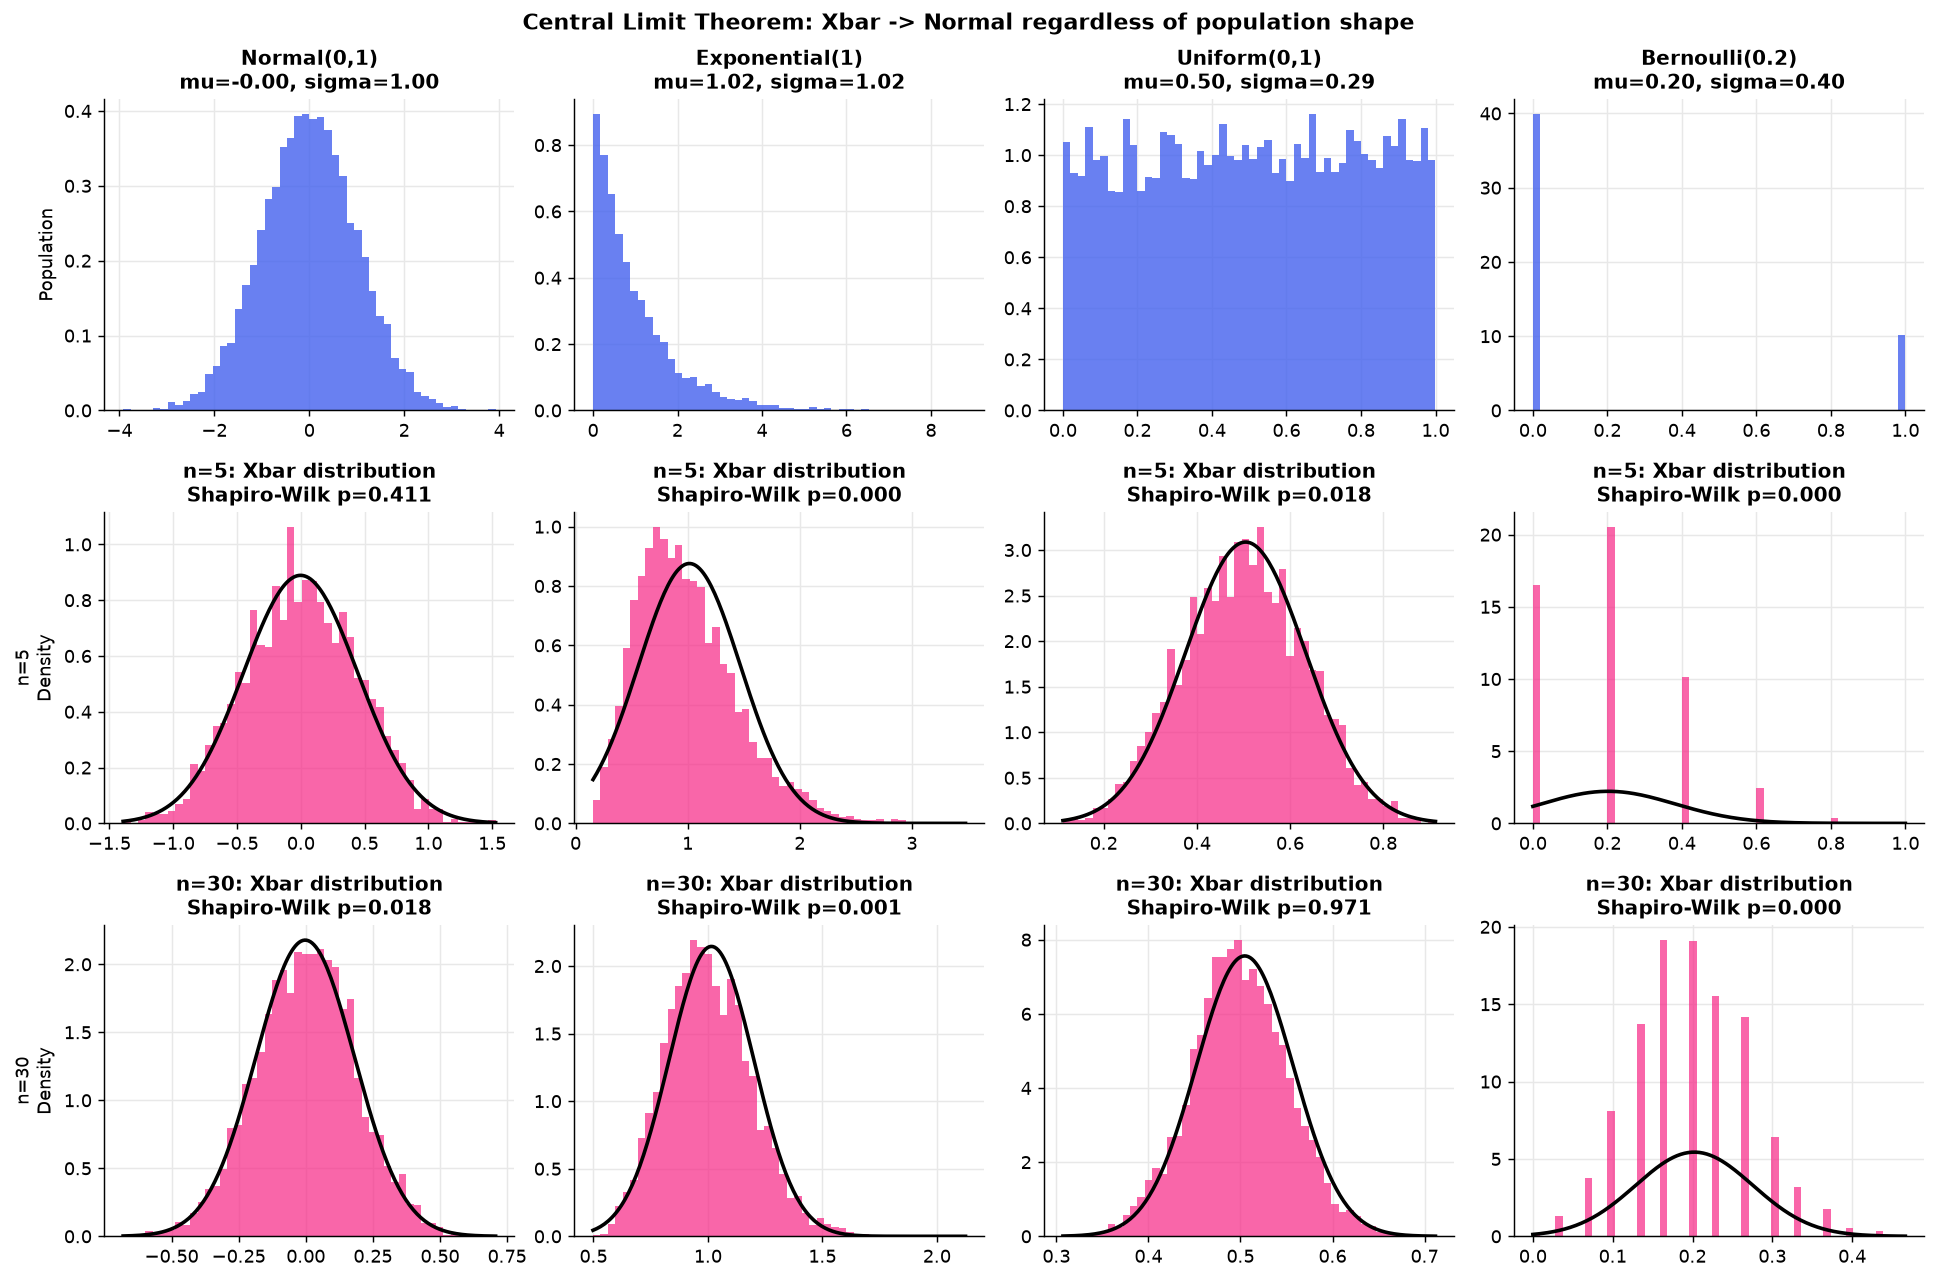

In [2]:
# ── CLT: sampling distribution from 4 different populations ─────────────
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

populations = {
    'Normal(0,1)':    lambda m: np.random.normal(0, 1, m),
    'Exponential(1)': lambda m: np.random.exponential(1, m),
    'Uniform(0,1)':   lambda m: np.random.uniform(0, 1, m),
    'Bernoulli(0.2)': lambda m: np.random.binomial(1, 0.2, m),
}
sample_sizes = [1, 5, 30]
B = 3000   # number of samples

for col, (pop_name, pop_fn) in enumerate(populations.items()):
    # Row 0: population
    pop_data = pop_fn(10000)
    axes[0, col].hist(pop_data, bins=50, color='#4361ee', alpha=0.8, density=True)
    axes[0, col].set_title(f'{pop_name}\nmu={pop_data.mean():.2f}, sigma={pop_data.std():.2f}')
    axes[0, col].set_ylabel('Density' if col==0 else '')

    # Rows 1,2: sampling distribution for n=5, n=30
    for row, n in enumerate([5, 30], start=1):
        xbars = [pop_fn(n).mean() for _ in range(B)]
        xbars = np.array(xbars)
        mu_pop, sigma_pop = pop_data.mean(), pop_data.std()
        x_range = np.linspace(xbars.min(), xbars.max(), 200)
        axes[row, col].hist(xbars, bins=50, color='#f72585', alpha=0.7, density=True)
        axes[row, col].plot(x_range,
            stats.norm.pdf(x_range, mu_pop, sigma_pop/np.sqrt(n)),
            color='black', lw=2, label='CLT')
        sw_stat, sw_p = stats.shapiro(xbars[:200])
        axes[row, col].set_title(f'n={n}: Xbar distribution\nShapiro-Wilk p={sw_p:.3f}')
        axes[row, col].set_ylabel('Density' if col==0 else '')
        if col==0: axes[row, col].set_ylabel(f'n={n}\nDensity')

axes[0,0].set_ylabel('Population')
plt.suptitle('Central Limit Theorem: Xbar -> Normal regardless of population shape',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Standard Error and confidence

The **standard error** SE = $\sigma/\sqrt{n}$ measures how much $\bar{X}$ varies across samples.

Key insight: SE is **not** the SD of the data — it is the SD of the *estimator*.
- SD describes spread in the population
- SE describes precision of the estimate

**Margin of error:** for 95% CI, the margin is $\approx 1.96 \times SE$.
Halving the margin of error requires 4x the sample size (because SE $\propto 1/\sqrt{n}$).

## Bootstrap: when CLT isn't enough

For complex statistics (median, correlation, quantiles), the CLT may not apply
or the formula for SE may be unknown. The **bootstrap** (Efron, 1979) estimates
the sampling distribution by resampling from the observed data:

1. Draw $B$ bootstrap samples of size $n$ **with replacement**
2. Compute the statistic on each bootstrap sample: $T^{(1)}, \ldots, T^{(B)}$
3. The distribution of $T^{(b)}$ approximates the sampling distribution of $T$

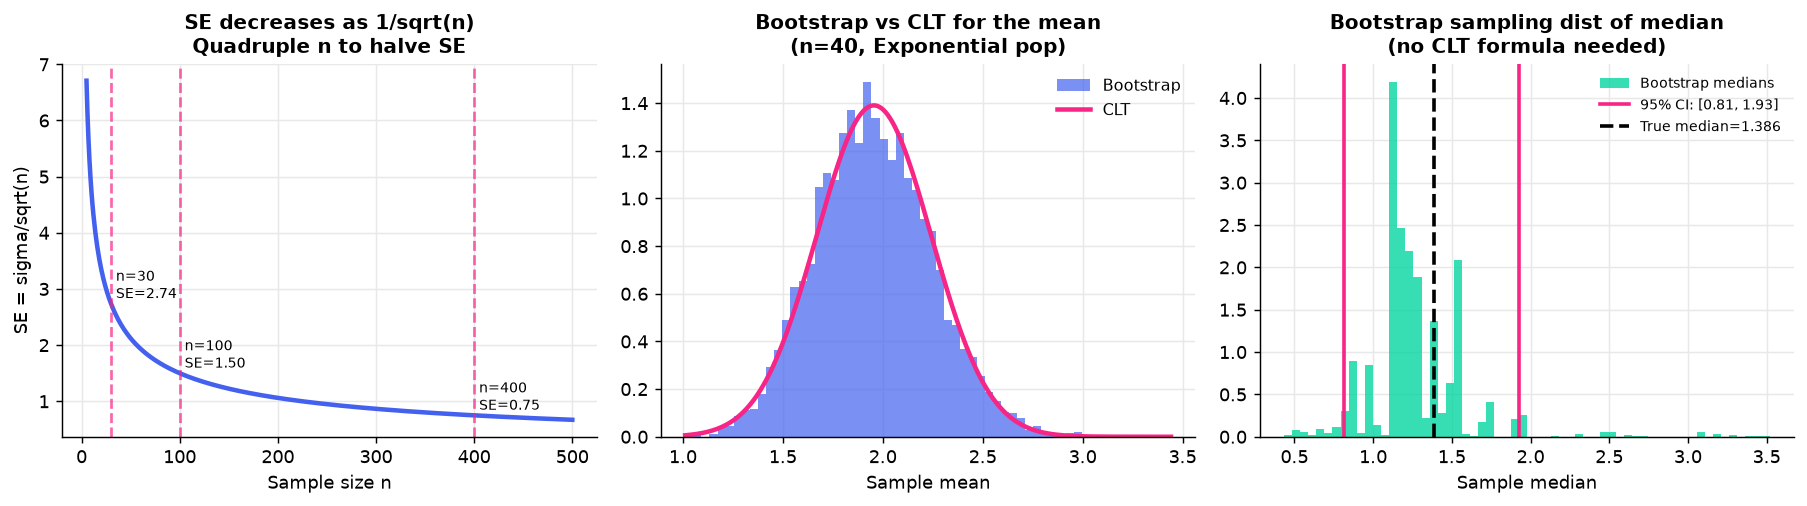

Bootstrap 95% CI for median: [0.813, 1.928]
True population median (Exp(2)): 1.386


In [3]:
# ── SE vs sample size + bootstrap vs CLT for the median ─────────────────
from scipy.stats import norm as Normal

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: SE vs n
ns = np.arange(5, 501)
sigma = 15  # known population SD
axes[0].plot(ns, sigma/np.sqrt(ns), color='#4361ee', lw=2.5)
for n_mark in [30, 100, 400]:
    axes[0].axvline(n_mark, color='#f72585', lw=1.5, linestyle='--', alpha=0.7)
    axes[0].text(n_mark+5, sigma/np.sqrt(n_mark)+0.1,
                 f'n={n_mark}\nSE={sigma/np.sqrt(n_mark):.2f}', fontsize=8)
axes[0].set_xlabel('Sample size n'); axes[0].set_ylabel('SE = sigma/sqrt(n)')
axes[0].set_title('SE decreases as 1/sqrt(n)\nQuadruple n to halve SE')

# Panel 2: Bootstrap vs CLT for the mean (exponential population)
pop = np.random.exponential(scale=2, size=10000)
sample = np.random.choice(pop, size=40, replace=False)

B = 5000
boot_means = [np.random.choice(sample, size=40, replace=True).mean() for _ in range(B)]
boot_means = np.array(boot_means)
x_range = np.linspace(boot_means.min(), boot_means.max(), 200)

axes[1].hist(boot_means, bins=60, density=True, color='#4361ee', alpha=0.7, label='Bootstrap')
axes[1].plot(x_range, Normal.pdf(x_range, sample.mean(), sample.std()/np.sqrt(40)),
             color='#f72585', lw=2.5, label='CLT')
axes[1].set_xlabel('Sample mean'); axes[1].set_title('Bootstrap vs CLT for the mean\n(n=40, Exponential pop)')
axes[1].legend(fontsize=9)

# Panel 3: Bootstrap for the median (no CLT formula!)
boot_medians = [np.median(np.random.choice(sample, size=40, replace=True)) for _ in range(B)]
boot_medians = np.array(boot_medians)
ci_lo, ci_hi = np.percentile(boot_medians, [2.5, 97.5])
axes[2].hist(boot_medians, bins=60, density=True, color='#06d6a0', alpha=0.8, label='Bootstrap medians')
axes[2].axvline(ci_lo, color='#f72585', lw=2, label=f'95% CI: [{ci_lo:.2f}, {ci_hi:.2f}]')
axes[2].axvline(ci_hi, color='#f72585', lw=2)
axes[2].axvline(np.log(2)*2, color='black', lw=2, linestyle='--', label=f'True median={np.log(2)*2:.3f}')
axes[2].set_xlabel('Sample median')
axes[2].set_title('Bootstrap sampling dist of median\n(no CLT formula needed)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Bootstrap 95% CI for median: [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'True population median (Exp(2)): {np.log(2)*2:.3f}')